In [1]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')
from src.visualizer import RAGVisualizer

Available experiments:
         experiment_name                   filename
7            most_fields           most_fields.json
11             high_text             high_text.json
12         high_question         high_question.json
10    global_most_fields    global_most_fields.json
0       global_high_text      global_high_text.json
6   global_high_question  global_high_question.json
5    global_cross_fields   global_cross_fields.json
3            global_bm25           global_bm25.json
9   global_baseline_bm25  global_baseline_bm25.json
8        global_balanced       global_balanced.json
4           cross_fields          cross_fields.json
2          baseline_bm25         baseline_bm25.json
1               balanced              balanced.json


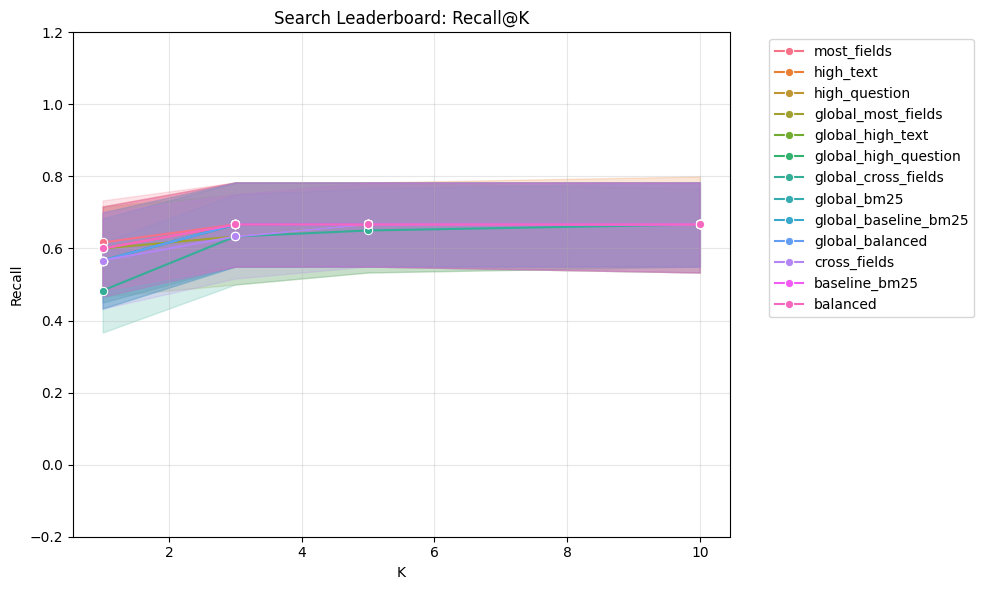

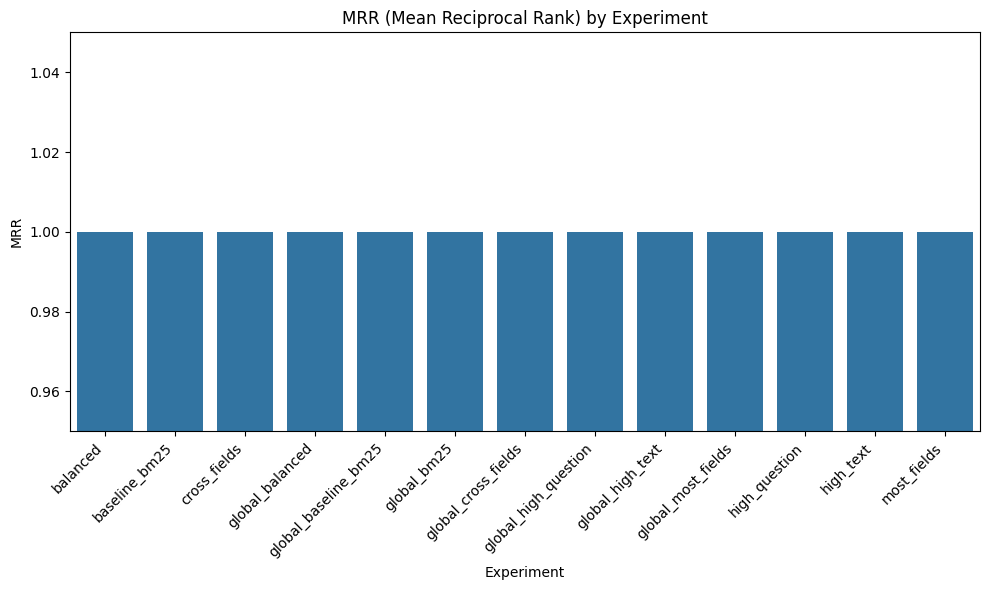

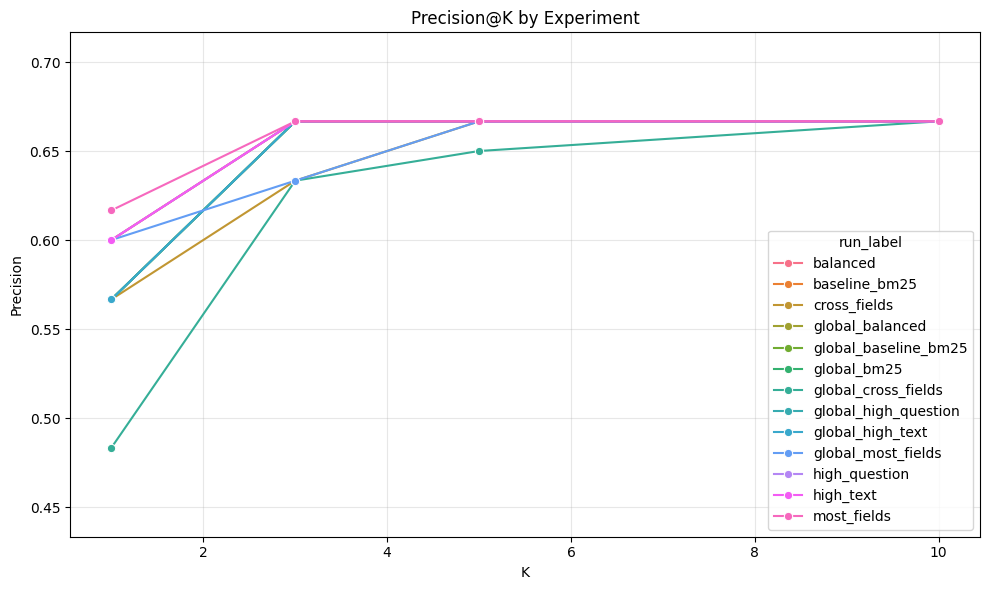

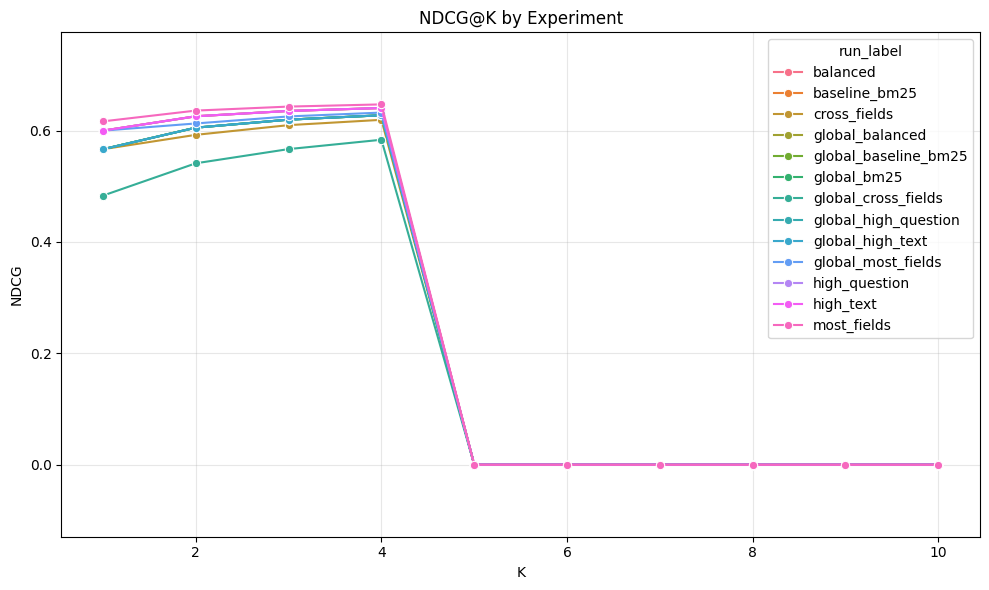

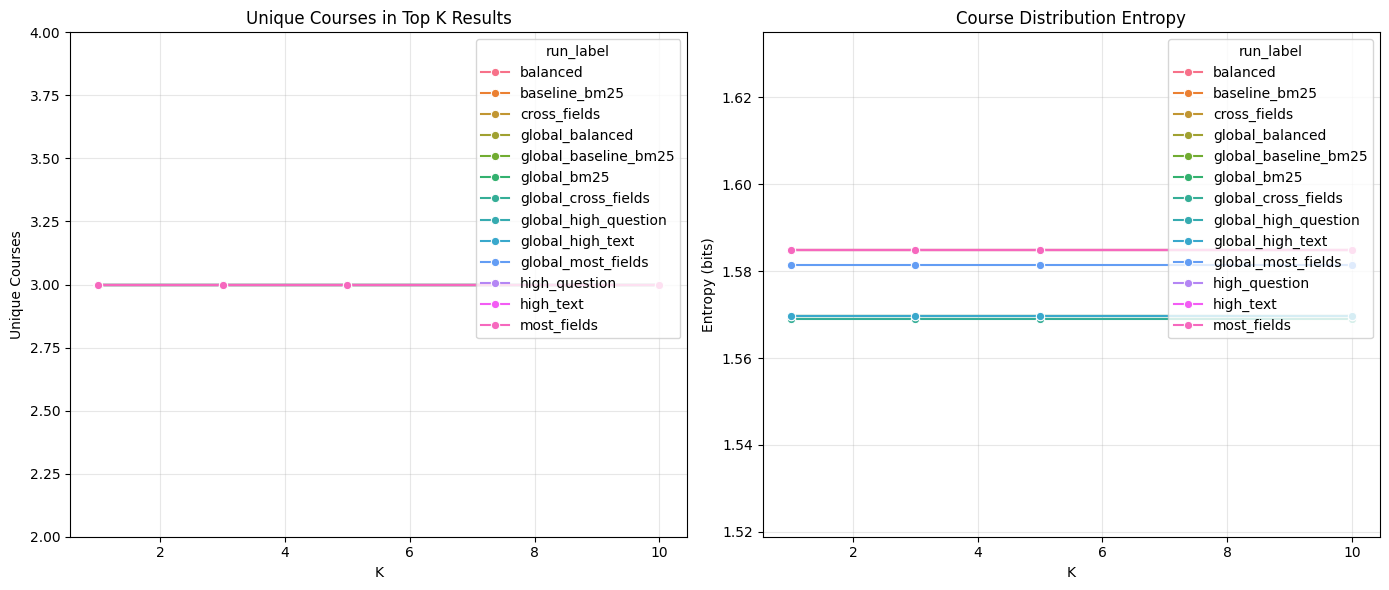

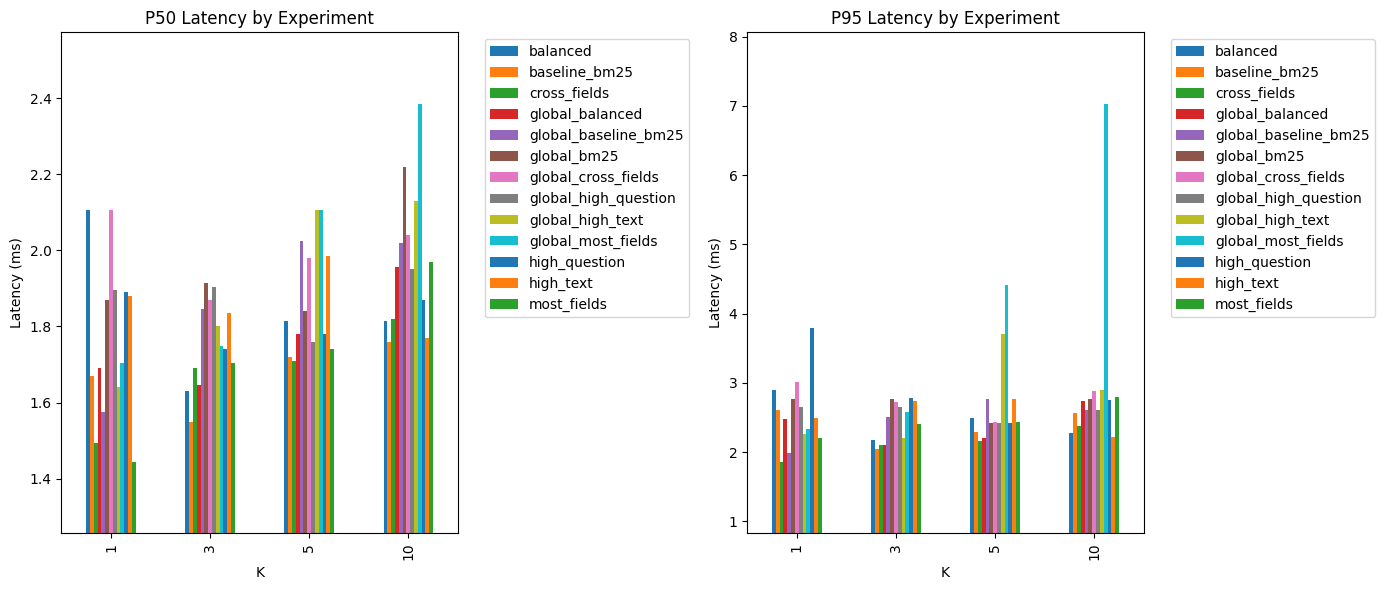

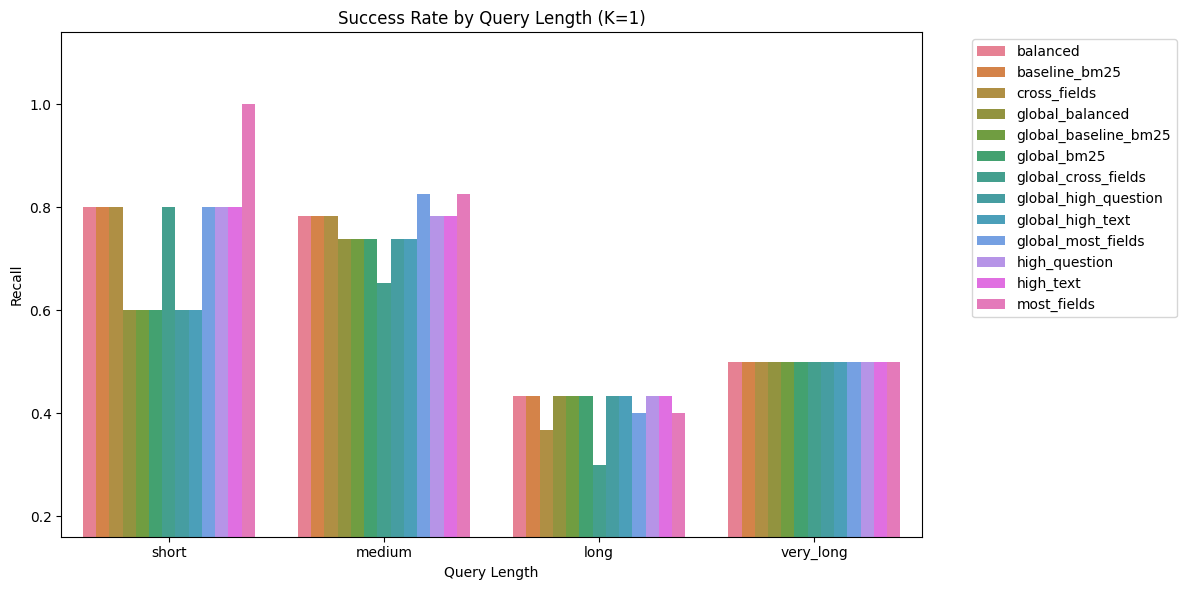

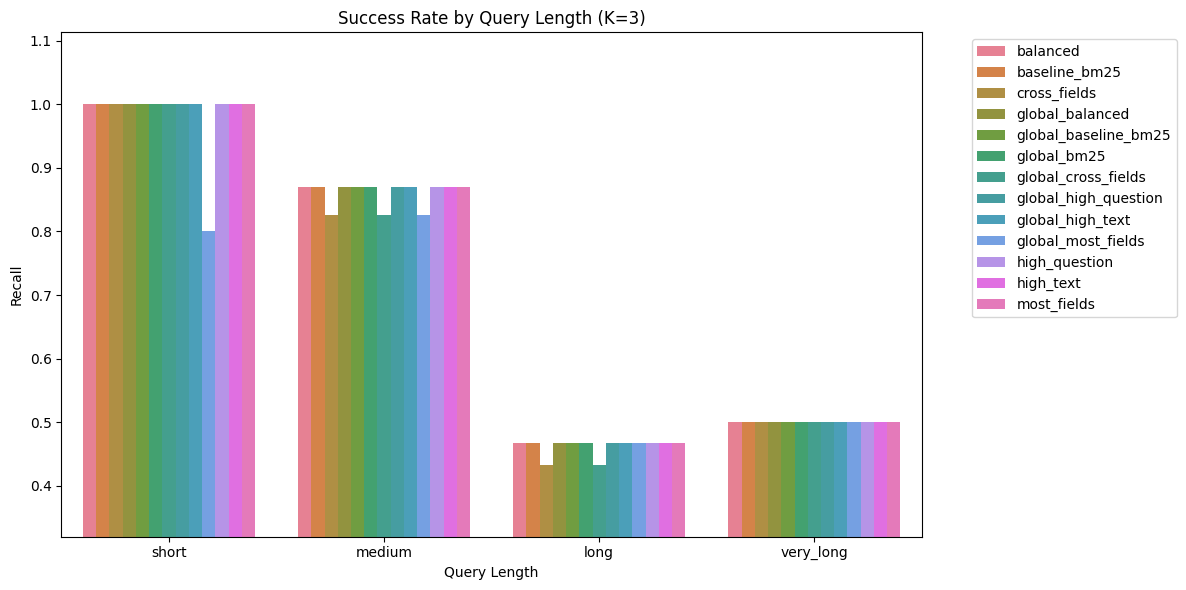

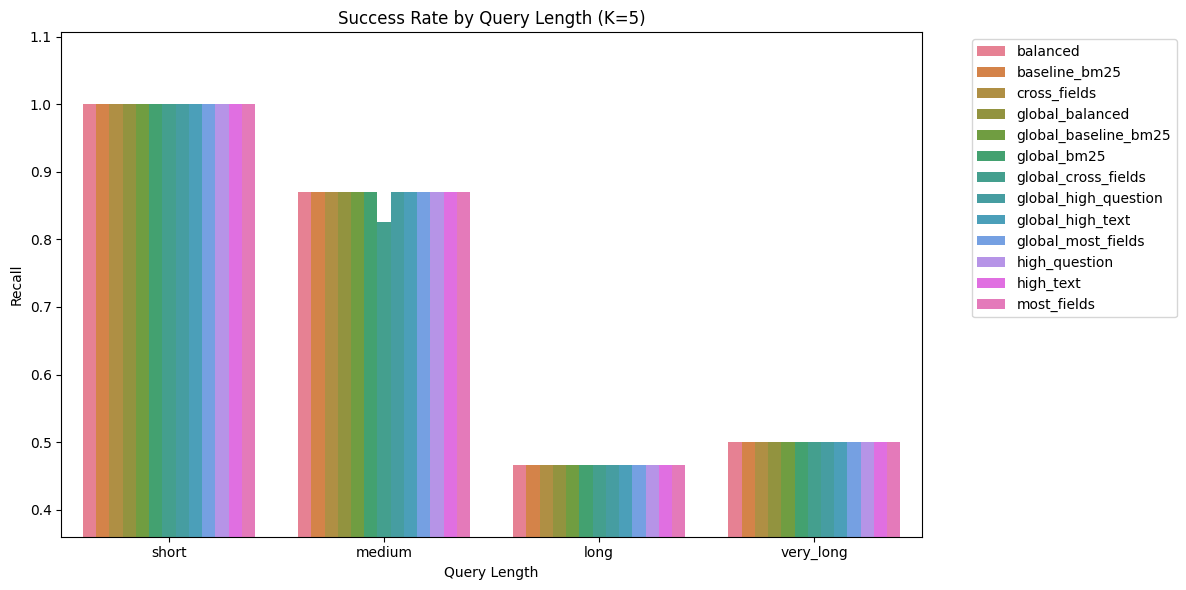

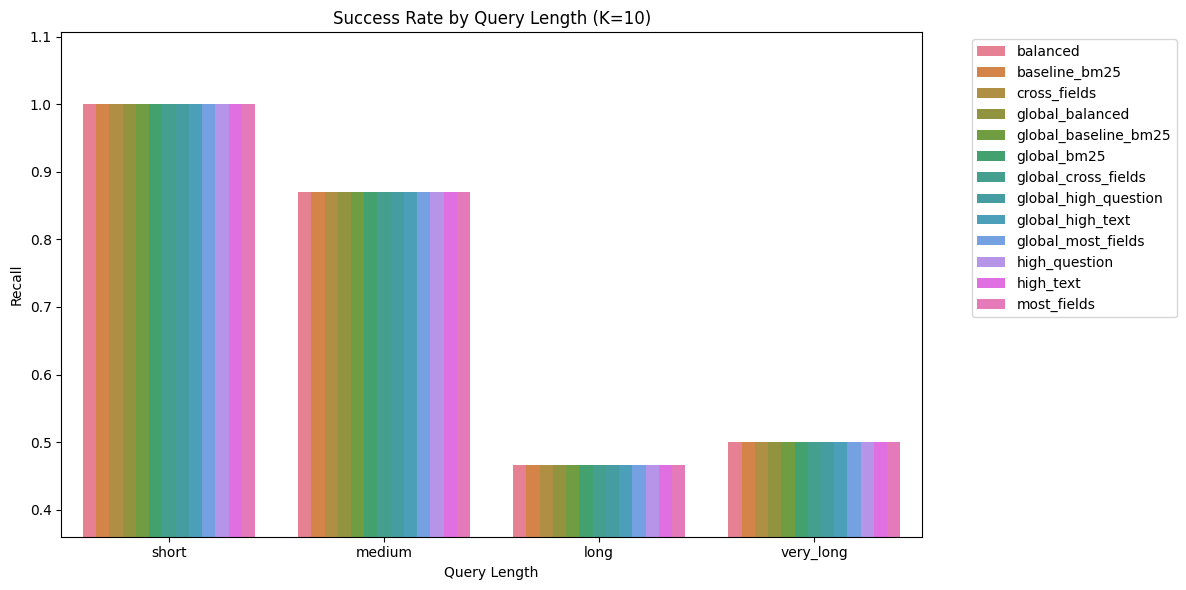

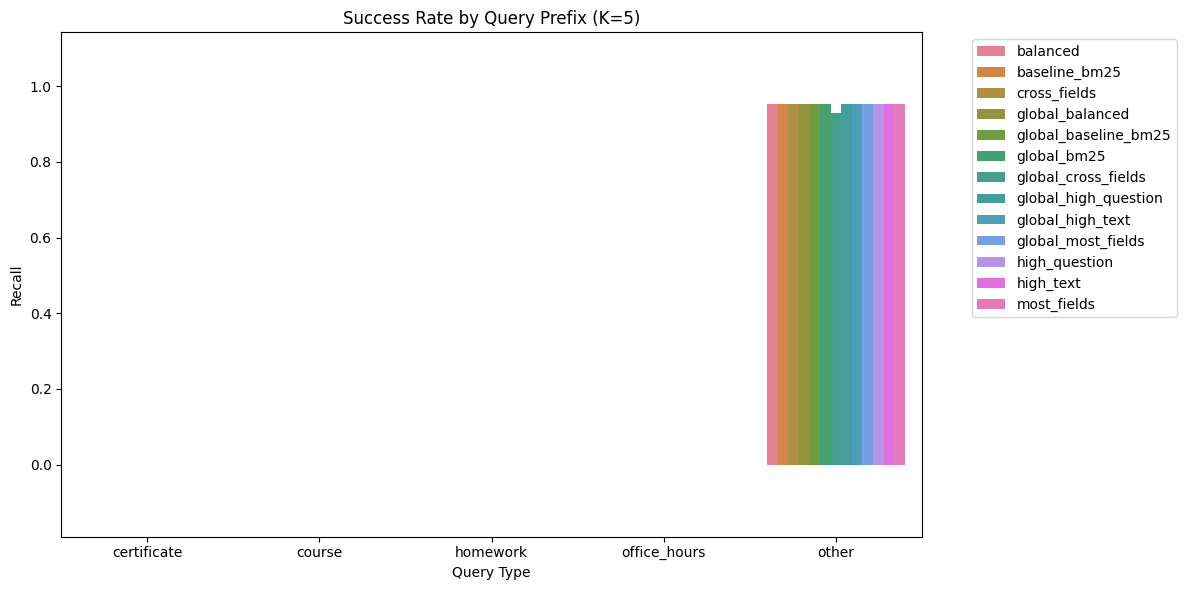


=== Comprehensive Summary (K=5) ===
                      recall@5  mrr  precision@5  hit_rate@5  unique_courses@5  entropy@5  p95_latency_ms
run_label                                                                                                
balanced                0.6667  1.0       0.6667      0.6667                 3     1.5850          2.5010
baseline_bm25           0.6667  1.0       0.6667      0.6667                 3     1.5850          2.2910
cross_fields            0.6667  1.0       0.6667      0.6667                 3     1.5850          2.1590
global_balanced         0.6667  1.0       0.6667      0.6667                 3     1.5696          2.2120
global_baseline_bm25    0.6667  1.0       0.6667      0.6667                 3     1.5696          2.7750
global_bm25             0.6667  1.0       0.6667      0.6667                 3     1.5696          2.4210
global_cross_fields     0.6500  1.0       0.6500      0.6500                 3     1.5689          2.4345
global_hi

In [8]:
from src.visualizer import main
main()


In [2]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
print(registry)

filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

summary = df[df['k'] == 5].groupby('run_label')['success'].mean()
print(summary.sort_values(ascending=False))

                     filename       experiment_name  \
7            most_fields.json           most_fields   
11             high_text.json             high_text   
12         high_question.json         high_question   
10    global_most_fields.json    global_most_fields   
0       global_high_text.json      global_high_text   
6   global_high_question.json  global_high_question   
5    global_cross_fields.json   global_cross_fields   
3            global_bm25.json           global_bm25   
9   global_baseline_bm25.json  global_baseline_bm25   
8        global_balanced.json       global_balanced   
4           cross_fields.json          cross_fields   
2          baseline_bm25.json         baseline_bm25   
1               balanced.json              balanced   

                      created_at  \
7  2026-05-04 12:19:35.216140509   
11 2026-05-04 12:19:34.744134903   
12 2026-05-04 12:19:34.232128620   
10 2026-05-04 12:19:33.720122576   
0  2026-05-04 12:19:33.156116009   
6  2026-05-04

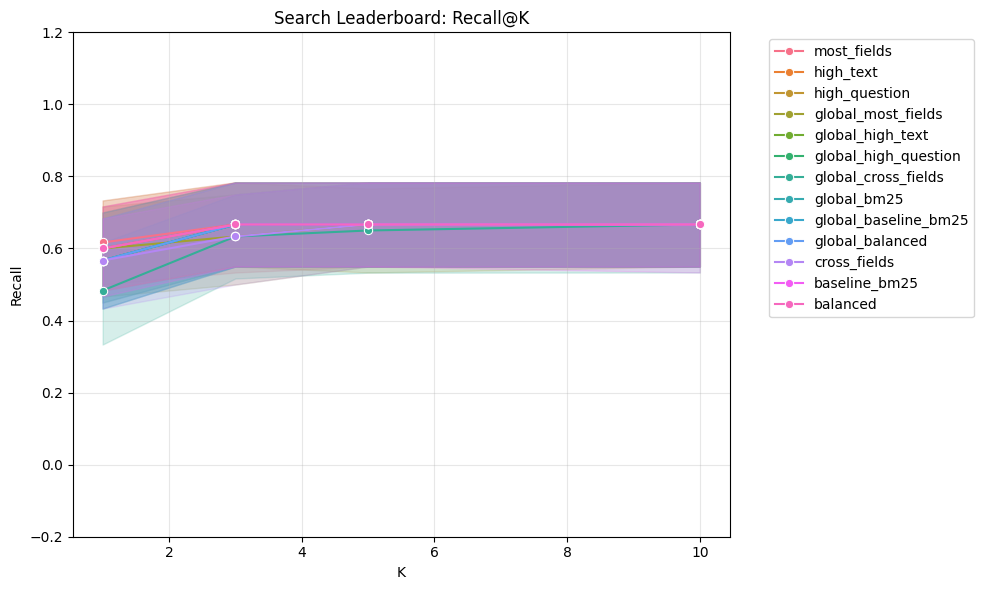

In [3]:
viz.plot_leaderboard(df)


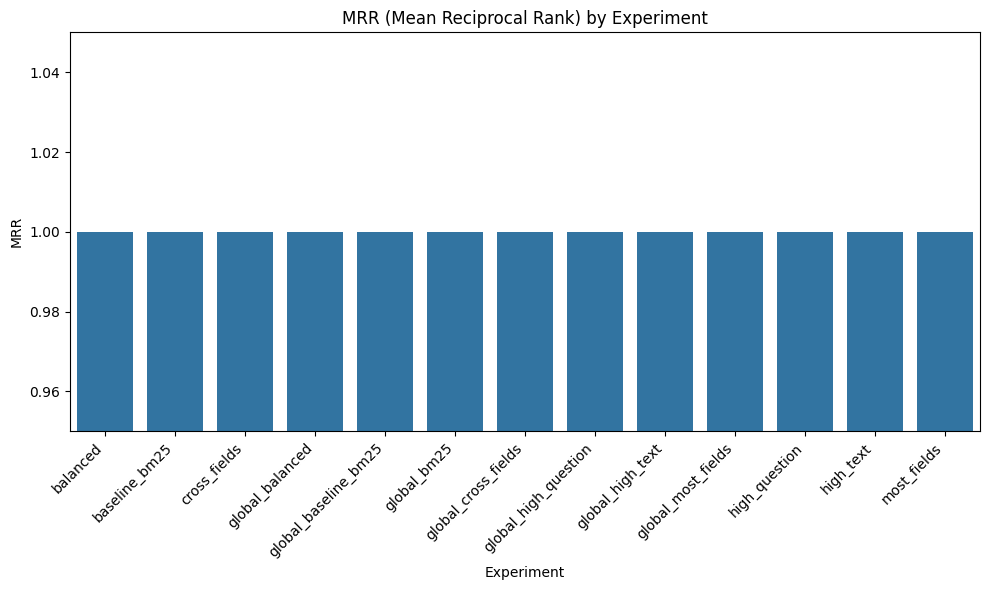

In [4]:
viz.plot_mrr_comparison(viz.compute_mrr(df))


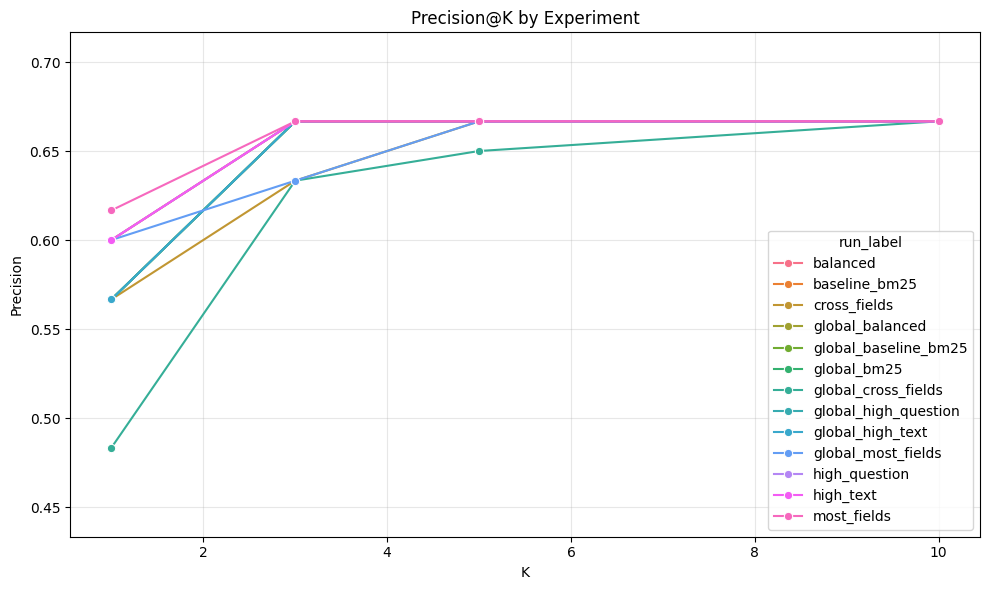

In [5]:
viz.plot_precision_at_k(viz.compute_precision_at_k(df))


In [9]:
def print_all_metrics_to_console(df: pd.DataFrame):
    print("\n" + "="*60)
    print("RETRIEVAL METRICS REPORT")
    print("="*60)
    
    for k in sorted(df['k'].unique()):
        print(f"\n--- K={k} ---")
        
        subset = df[df['k'] == k]
        
        for run in subset['run_label'].unique():
            run_data = subset[subset['run_label'] == run]
            
            recall = run_data['success'].mean()
            precision = run_data['success'].mean()
            hit_rate = run_data['success'].mean()
            avg_latency = run_data['latency_ms'].mean()
            p95_latency = run_data['latency_ms'].quantile(0.95)
            unique_courses = run_data['found_course'].nunique()
            
            print(f"\n  {run}:")
            print(f"    Recall@{k}: {recall:.4f}")
            print(f"    Precision@{k}: {precision:.4f}")
            print(f"    Hit Rate@{k}: {hit_rate:.4f}")
            print(f"    Avg Latency: {avg_latency:.2f} ms")
            print(f"    P95 Latency: {p95_latency:.2f} ms")
            print(f"    Unique Courses in Top {k}: {unique_courses}")
    
    print("\n" + "="*60)
    print("CROSS-COURSE ANALYSIS")
    print("="*60)
    
    df['is_cross_course'] = df['expected_course'] != df['found_course']
    cross_rate = df.groupby(['run_label', 'k'])['is_cross_course'].mean()
    print("\n", cross_rate.to_string())
    
    print("\n" + "="*60)
    print("PER-COURSE BREAKDOWN (K=5)")
    print("="*60)
    
    df_k5 = df[df['k'] == 5]
    course_perf = df_k5.groupby(['run_label', 'expected_course'])['success'].mean()
    print("\n", course_perf.to_string())


# Run it
print_all_metrics_to_console(df)


RETRIEVAL METRICS REPORT

--- K=1 ---

  most_fields:
    Recall@1: 0.6167
    Precision@1: 0.6167
    Hit Rate@1: 0.6167
    Avg Latency: 1.57 ms
    P95 Latency: 2.21 ms
    Unique Courses in Top 1: 3

  high_text:
    Recall@1: 0.6000
    Precision@1: 0.6000
    Hit Rate@1: 0.6000
    Avg Latency: 1.91 ms
    P95 Latency: 2.49 ms
    Unique Courses in Top 1: 3

  high_question:
    Recall@1: 0.6000
    Precision@1: 0.6000
    Hit Rate@1: 0.6000
    Avg Latency: 2.02 ms
    P95 Latency: 3.79 ms
    Unique Courses in Top 1: 3

  global_most_fields:
    Recall@1: 0.6000
    Precision@1: 0.6000
    Hit Rate@1: 0.6000
    Avg Latency: 1.78 ms
    P95 Latency: 2.33 ms
    Unique Courses in Top 1: 3

  global_high_text:
    Recall@1: 0.5667
    Precision@1: 0.5667
    Hit Rate@1: 0.5667
    Avg Latency: 1.67 ms
    P95 Latency: 2.27 ms
    Unique Courses in Top 1: 3

  global_high_question:
    Recall@1: 0.5667
    Precision@1: 0.5667
    Hit Rate@1: 0.5667
    Avg Latency: 1.95 ms
    P9

In [10]:
ndcg_df = viz.compute_ndcg(df)
print(ndcg_df)

       run_label   k      ndcg
0       balanced   1  0.600000
1       balanced   2  0.625790
2       balanced   3  0.635381
3       balanced   4  0.640641
4       balanced   5  0.000000
..           ...  ..       ...
125  most_fields   6  0.000000
126  most_fields   7  0.000000
127  most_fields   8  0.000000
128  most_fields   9  0.000000
129  most_fields  10  0.000000

[130 rows x 3 columns]


In [11]:
import json
from collections import Counter

with open("/home/admin/LLM/LLM/01/web/documents.json", "r") as f:
    data = json.load(f)

# See what each course covers
for course in data:
    print(f"\n=== {course['course']} ===")
    questions = [doc['question'] for doc in course['documents']]
    print(f"Total questions: {len(questions)}")
    print("Sample questions:")
    for q in questions[:3]:
        print(f"  - {q}")

# Check for overlapping keywords across courses
all_terms = {}
for course in data:
    terms = []
    for doc in course['documents']:
        terms.extend(doc['question'].lower().split())
        terms.extend(doc['text'].lower().split()[:50])
    all_terms[course['course']] = Counter(terms).most_common(10)
    print(f"\n{course['course']} top terms:")
    print(all_terms[course['course']])


=== data-engineering-zoomcamp ===
Total questions: 435
Sample questions:
  - Course - When will the course start?
  - Course - What are the prerequisites for this course?
  - Course - Can I still join the course after the start date?

=== machine-learning-zoomcamp ===
Total questions: 375
Sample questions:
  - How do I sign up?
  - Is it going to be live? When?
  - What if I miss a session?

=== mlops-zoomcamp ===
Total questions: 138
Sample questions:
  - Format for questions: [Problem title]
  - What is the expected duration of this course or that for each module?
  - What’s the difference between the 2023 and 2022 course?

data-engineering-zoomcamp top terms:
[('the', 1103), ('to', 711), ('in', 408), ('you', 378), ('-', 308), ('a', 304), ('and', 294), ('is', 266), ('not', 219), ('for', 212)]

machine-learning-zoomcamp top terms:
[('the', 1062), ('to', 542), ('in', 324), ('and', 293), ('you', 276), ('a', 276), ('is', 273), ('for', 244), ('of', 240), ('i', 186)]

mlops-zoomcamp top t

In [12]:
from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
print(registry)

filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)

# Compare all experiments
summary = df[df['k'] == 5].groupby('run_label')['success'].mean()
print(summary.sort_values(ascending=False))

                     filename       experiment_name  \
7            most_fields.json           most_fields   
11             high_text.json             high_text   
12         high_question.json         high_question   
10    global_most_fields.json    global_most_fields   
0       global_high_text.json      global_high_text   
6   global_high_question.json  global_high_question   
5    global_cross_fields.json   global_cross_fields   
3            global_bm25.json           global_bm25   
9   global_baseline_bm25.json  global_baseline_bm25   
8        global_balanced.json       global_balanced   
4           cross_fields.json          cross_fields   
2          baseline_bm25.json         baseline_bm25   
1               balanced.json              balanced   

                      created_at  \
7  2026-05-04 12:19:35.216140509   
11 2026-05-04 12:19:34.744134903   
12 2026-05-04 12:19:34.232128620   
10 2026-05-04 12:19:33.720122576   
0  2026-05-04 12:19:33.156116009   
6  2026-05-04

In [13]:
import sys
import os
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')
os.chdir('/home/admin/LLM/LLM/01/web')

from src.search import CourseRAGManager
from src.config_manager import load_config
# /home/admin/LLM/LLM/01/web/analyze_terms.py

import json
from collections import Counter
from nltk.corpus import stopwords
import nltk

# Download stopwords if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

with open("documents.json", "r") as f:
    data = json.load(f)

for course in data:
    print(f"\n=== {course['course']} ===")
    
    all_words = []
    for doc in course['documents']:
        # Clean the question
        question = doc['question']
        if " - " in question:
            question = question.split(" - ", 1)[1].strip()
        
        # Split and filter
        words = question.lower().split()
        words = [w for w in words if w not in stop_words and len(w) > 2]
        all_words.extend(words)
        
        # Also analyze text field (first 200 chars)
        text_words = doc['text'].lower().split()[:50]
        text_words = [w for w in text_words if w not in stop_words and len(w) > 2]
        all_words.extend(text_words)
    
    top_terms = Counter(all_words).most_common(20)
    print(f"Top meaningful terms:")
    for term, count in top_terms:
        print(f"  {term}: {count}")


=== data-engineering-zoomcamp ===
Top meaningful terms:
  error: 158
  docker: 126
  run: 114
  use: 108
  data: 101
  using: 99
  file: 93
  dbt: 70
  install: 68
  error:: 65
  create: 62
  running: 60
  files: 59
  python: 57
  need: 56
  project: 55
  command: 54
  bigquery: 51
  check: 50
  spark: 48

=== machine-learning-zoomcamp ===
Top meaningful terms:
  use: 118
  error: 111
  docker: 104
  using: 92
  get: 73
  install: 67
  run: 62
  model: 61
  need: 48
  command: 47
  image: 47
  import: 44
  running: 43
  data: 42
  one: 41
  solution: 40
  added: 39
  getting: 38
  file: 38
  python: 36

=== mlops-zoomcamp ===
Top meaningful terms:
  error: 49
  mlflow: 44
  using: 43
  added: 38
  aws: 35
  problem: 33
  running: 32
  solution:: 32
  get: 30
  install: 29
  description: 29
  use: 27
  run: 27
  problem:: 26
  command: 25
  solution: 24
  following: 23
  file: 23
  jupyter: 21
  set: 21


[nltk_data] Downloading package stopwords to /home/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
import json
from src.search import CourseRAGManager
from src.config_manager import load_config

# Load a Data Engineering query
with open("documents.json", "r") as f:
    data = json.load(f)

de_course = [c for c in data if c["course"] == "data-engineering-zoomcamp"][0]
sample_doc = de_course["documents"][0]
sample_query = sample_doc["question"].replace("Course - ", "").strip()

print(f"Query: {sample_query}")
print(f"Expected text snippet: {sample_doc['text'][:100]}...")

# Run search
settings = load_config("experiments/configs/baseline_bm25.json")
manager = CourseRAGManager(settings)
manager.connect_elasticsearch()

results = manager.search_faq(sample_query, override_size=5, course_context=None)

print("\n=== Top 5 Results ===")
for i, hit in enumerate(results):
    print(f"{i+1}. Course: {hit['_source']['course']}")
    print(f"   Question: {hit['_source']['question'][:50]}...")
    print(f"   Score: {hit['_score']}")
    print()

2026-05-04 12:53:38,958 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 12:53:38,960 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 12:53:38,965 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.004s]


Query: When will the course start?
Expected text snippet: The purpose of this document is to capture frequently asked technical questions
The exact day and ho...

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 12:53:38,966 [INFO] - Function 'search_faq' executed in 0.0049s

=== Top 5 Results ===
1. Course: machine-learning-zoomcamp
   Question: Is it going to be live? When?...
   Score: 10.974446

2. Course: data-engineering-zoomcamp
   Question: When will the course start?...
   Score: 10.581708

3. Course: data-engineering-zoomcamp
   Question: Can I follow the course after it finishes?...
   Score: 9.910858

4. Course: machine-learning-zoomcamp
   Question: The course videos are from the previous iteration....
   Score: 9.270394

5. Course: machine-learning-zoomcamp
   Question: I just joined. What should I do next? How can I ac...
   Score: 9.207565



In [15]:
configs_to_test = [
    "baseline_bm25",
    "cross_fields", 
    "high_question",
    "global_cross_fields"
]

for config_name in configs_to_test:
    settings = load_config(f"experiments/configs/{config_name}.json")
    manager = CourseRAGManager(settings)
    manager.connect_elasticsearch()
    
    results = manager.search_faq("When will the course start?", override_size=3, course_context=None)
    
    print(f"\n=== {config_name} ===")
    for hit in results:
        print(f"{hit['_source']['course']}: {hit['_source']['question'][:40]}... (score: {hit['_score']:.2f})")

2026-05-04 12:53:50,393 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 12:53:50,396 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 12:53:50,399 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 12:53:50,400 [INFO] - Function 'search_faq' executed in 0.0039s


2026-05-04 12:53:50,404 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 12:53:50,405 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 12:53:50,409 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



=== baseline_bm25 ===
machine-learning-zoomcamp: Is it going to be live? When?... (score: 10.97)
data-engineering-zoomcamp: When will the course start?... (score: 10.58)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.91)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 12:53:50,410 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-04 12:53:50,413 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 12:53:50,415 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 12:53:50,419 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]



=== cross_fields ===
machine-learning-zoomcamp: Is it going to be live? When?... (score: 11.75)
data-engineering-zoomcamp: When will the course start?... (score: 11.44)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.91)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 12:53:50,420 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-04 12:53:50,424 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 12:53:50,426 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 12:53:50,430 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



=== high_question ===
machine-learning-zoomcamp: Is it going to be live? When?... (score: 10.97)
data-engineering-zoomcamp: When will the course start?... (score: 10.58)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.91)

🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 12:53:50,431 [INFO] - Function 'search_faq' executed in 0.0034s

=== global_cross_fields ===
machine-learning-zoomcamp: Is it going to be live? When?... (score: 11.75)
data-engineering-zoomcamp: When will the course start?... (score: 11.44)
data-engineering-zoomcamp: Can I follow the course after it finishe... (score: 9.91)


In [17]:
import json
import glob

for filepath in glob.glob("experiments/configs/*.json"):
    with open(filepath, 'r') as f:
        config = json.load(f)
    
    config["minimum_should_match"] = "60%"
    
    with open(filepath, 'w') as f:
        json.dump(config, f, indent=4)
    print(f"Updated: {filepath}")

Updated: experiments/configs/global_high_text.json
Updated: experiments/configs/balanced.json
Updated: experiments/configs/baseline_bm25.json
Updated: experiments/configs/global_bm25.json
Updated: experiments/configs/cross_fields.json
Updated: experiments/configs/global_cross_fields.json
Updated: experiments/configs/global_high_question.json
Updated: experiments/configs/most_fields.json
Updated: experiments/configs/global_balanced.json
Updated: experiments/configs/global_baseline_bm25.json
Updated: experiments/configs/global_most_fields.json
Updated: experiments/configs/high_text.json
Updated: experiments/configs/high_question.json
